## Dataset Variables

The columns in O2O2_collisions.csv represent the following variables:

| Column | Variable |
|--------|----------|
| 0 | v1_in(1) |
| 1 | v1_in(2) |
| 2 | v1_in(3) |
| 3 | v2_in(1) |
| 4 | v2_in(2) |
| 5 | v2_in(3) |
| 6 | omega1_in(1) |
| 7 | omega1_in(2) |
| 8 | omega1_in(3) |
| 9 | omega2_in(1) |
| 10 | omega2_in(2) |
| 11 | omega2_in(3) |
| 12 | v1_out(1) |
| 13 | v1_out(2) |
| 14 | v1_out(3) |
| 15 | v2_out(1) |
| 16 | v2_out(2) |
| 17 | v2_out(3) |
| 18 | omega1_out(1) |
| 19 | omega1_out(2) |
| 20 | omega1_out(3) |
| 21 | omega2_out(1) |
| 22 | omega2_out(2) |
| 23 | omega2_out(3) |

# Model Exploration
A notebook to explore and analyze different machine learning models and their performance on the oxygen dataset.

In [1]:
import numpy as np

DATA = "../oxygen_data_aldo/Run/O2O2_collisions.csv"
rawdata = np.loadtxt(DATA, delimiter=',')

FileNotFoundError: ../oxygen_data_aldo/Run/O2O2_collisions.csv not found.

# Mixeture Density Networks (MDN)

A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

#### Dataset Preparation

In [ ]:
# Create Dataloaders for training and validation (with normalization)
import torch
from torch.utils.data import DataLoader, TensorDataset, Subset

# Select pre-collisional velocities and angular velocities of molecule 1
inputdata = np.c_[rawdata[:, 0:3], rawdata[:, 6:9]]
outputdata = np.c_[rawdata[:, 12:15], rawdata[:, 18:21]]

inputs = torch.tensor(inputdata, dtype=torch.float32)
outputs = torch.tensor(outputdata, dtype=torch.float32)

dataset = TensorDataset(inputs, outputs)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Reproducible split (avoid val-stat leakage into normalization)
generator = torch.Generator().manual_seed(0)
train_subset, val_subset = torch.utils.data.random_split(dataset, [train_size, val_size], generator=generator)

train_idx = torch.tensor(train_subset.indices, dtype=torch.long)
val_idx = torch.tensor(val_subset.indices, dtype=torch.long)

# Compute normalization statistics on training data only
eps = 1e-8
in_mean = inputs[train_idx].mean(dim=0, keepdim=True)
in_std = inputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)
out_mean = outputs[train_idx].mean(dim=0, keepdim=True)
out_std = outputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)

# Normalize full tensors, then re-wrap using the same split indices
inputs_norm = (inputs - in_mean) / in_std
outputs_norm = (outputs - out_mean) / out_std
dataset_norm = TensorDataset(inputs_norm, outputs_norm)

train_dataset = Subset(dataset_norm, train_idx.tolist())
val_dataset = Subset(dataset_norm, val_idx.tolist())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print("Input mean:", in_mean.flatten().tolist())
print("Input std :", in_std.flatten().tolist())
print("Output mean:", out_mean.flatten().tolist())
print("Output std :", out_std.flatten().tolist())

Input mean: [0.3275602161884308, -0.6079530715942383, 0.6246814727783203, -4869330432.0, 254280624.0, -2404565248.0]
Input std : [278.6170654296875, 279.4554748535156, 279.1385192871094, 3771219836928.0, 3765414395904.0, 3773620551680.0]
Output mean: [0.24669340252876282, -0.3720771074295044, 0.6171222925186157, -5936222208.0, 3734816256.0, -4197971456.0]
Output std : [279.331298828125, 279.92034912109375, 279.7886657714844, 3755981144064.0, 3750743506944.0, 3758074363904.0]


#### Model Definition

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MixtureDensityNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, num_mixtures, hidden_dim=128):
        super().__init__()
        self.K = num_mixtures
        self.D = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.pi_layer = nn.Linear(hidden_dim, self.K)
        self.mu_layer = nn.Linear(hidden_dim, self.K * self.D)
        self.sigma_layer = nn.Linear(hidden_dim, self.K * self.D)

    def forward(self, x):
        h = self.net(x)

        # Mixture weights
        pi = F.softmax(self.pi_layer(h), dim=-1)

        # Means
        mu = self.mu_layer(h)
        mu = mu.view(-1, self.K, self.D)

        # Standard deviations
        sigma = self.sigma_layer(h)
        sigma = F.softplus(sigma) + 1e-6  # Ensure positivity
        # sigma = torch.exp(sigma)
        sigma = sigma.view(-1, self.K, self.D)

        return pi, mu, sigma

#### Define loss function

In [ ]:
def mdn_loss(pi, mu, sigma, y):
    """
    Computes the negative log-likelihood loss for a Mixture Density Network.
    Args:
        pi: Mixture weights, shape (batch_size, K)
        mu: Means of the mixtures, shape (batch_size, K, D)
        sigma: Standard deviations of the mixtures, shape (batch_size, K, D)
        y: Target values, shape (batch_size, D)
    """
    y = y.unsqueeze(1)  # Shape (batch_size, 1, D)

    # Gaussian probability density function
    log_prob = -0.5 * (
        torch.sum(((y - mu) / sigma) ** 2, dim=2)
        + torch.sum(torch.log(sigma ** 2), dim=2)
        + mu.size(2) * torch.log(torch.tensor(2 * torch.pi))
    )  # Shape (batch_size, K)

    # Weighted log probabilities
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    log_sum_exp = torch.logsumexp(weighted_log_prob, dim=1) 

    return -torch.mean(log_sum_exp)

#### Training

In [ ]:
K = 5
output_dim = 6

model = MixtureDensityNetwork(
    input_dim=6,
    output_dim=output_dim,
    num_mixtures=K
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 50
train_loss_hist = np.zeros(num_epochs)
val_loss_hist = np.zeros(num_epochs)

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for inputs, outputs in train_loader:
        optimizer.zero_grad()
        pi, mu, sigma = model(inputs)
        loss = mdn_loss(pi, mu, sigma, outputs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_loss_hist[epoch] = train_loss
    print(f"Epoch {epoch+1}, Training Loss: {train_loss:.4f}")

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for inputs, outputs in val_loader:
            pi, mu, sigma = model(inputs)
            loss = mdn_loss(pi, mu, sigma, outputs)
            val_loss += loss.item()

        val_loss /= len(val_loader)
        val_loss_hist[epoch] = val_loss
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss_hist[epoch]:.4f}")

torch.save(model.state_dict(), "mdn_o2o2_collision_model.pth")

Epoch 1, Training Loss: -4.1850
Epoch 1, Validation Loss: -7.3111
Epoch 2, Training Loss: -8.2373
Epoch 2, Validation Loss: -9.0598
Epoch 3, Training Loss: -9.6110
Epoch 3, Validation Loss: -10.1822
Epoch 4, Training Loss: -10.6403
Epoch 4, Validation Loss: -11.0333
Epoch 5, Training Loss: -11.5682
Epoch 5, Validation Loss: -11.9316
Epoch 6, Training Loss: -12.4077
Epoch 6, Validation Loss: -12.6914
Epoch 7, Training Loss: -13.0879
Epoch 7, Validation Loss: -13.1263
Epoch 8, Training Loss: -13.5847
Epoch 8, Validation Loss: -13.8865
Epoch 9, Training Loss: -13.9509
Epoch 9, Validation Loss: -14.1974
Epoch 10, Training Loss: -14.2035
Epoch 10, Validation Loss: -14.0596
Epoch 11, Training Loss: -14.3579
Epoch 11, Validation Loss: -14.0648
Epoch 12, Training Loss: -14.4513
Epoch 12, Validation Loss: -14.4916
Epoch 13, Training Loss: -14.5249
Epoch 13, Validation Loss: -14.4952
Epoch 14, Training Loss: -14.5394
Epoch 14, Validation Loss: -14.7955
Epoch 15, Training Loss: -14.5992
Epoch 15,

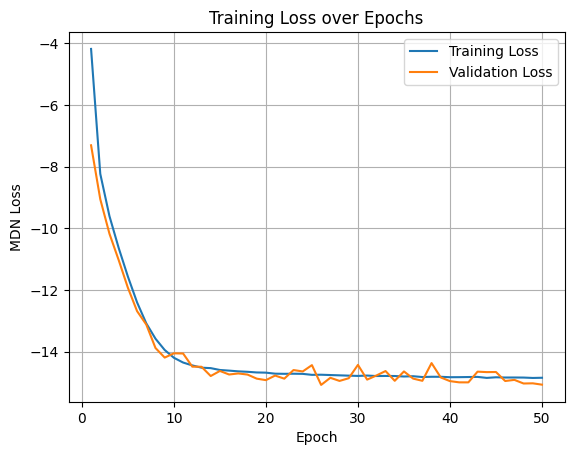

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), train_loss_hist, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_loss_hist, label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MDN Loss')
plt.title('Training Loss over Epochs')
plt.grid()
plt.show()

# Visualization

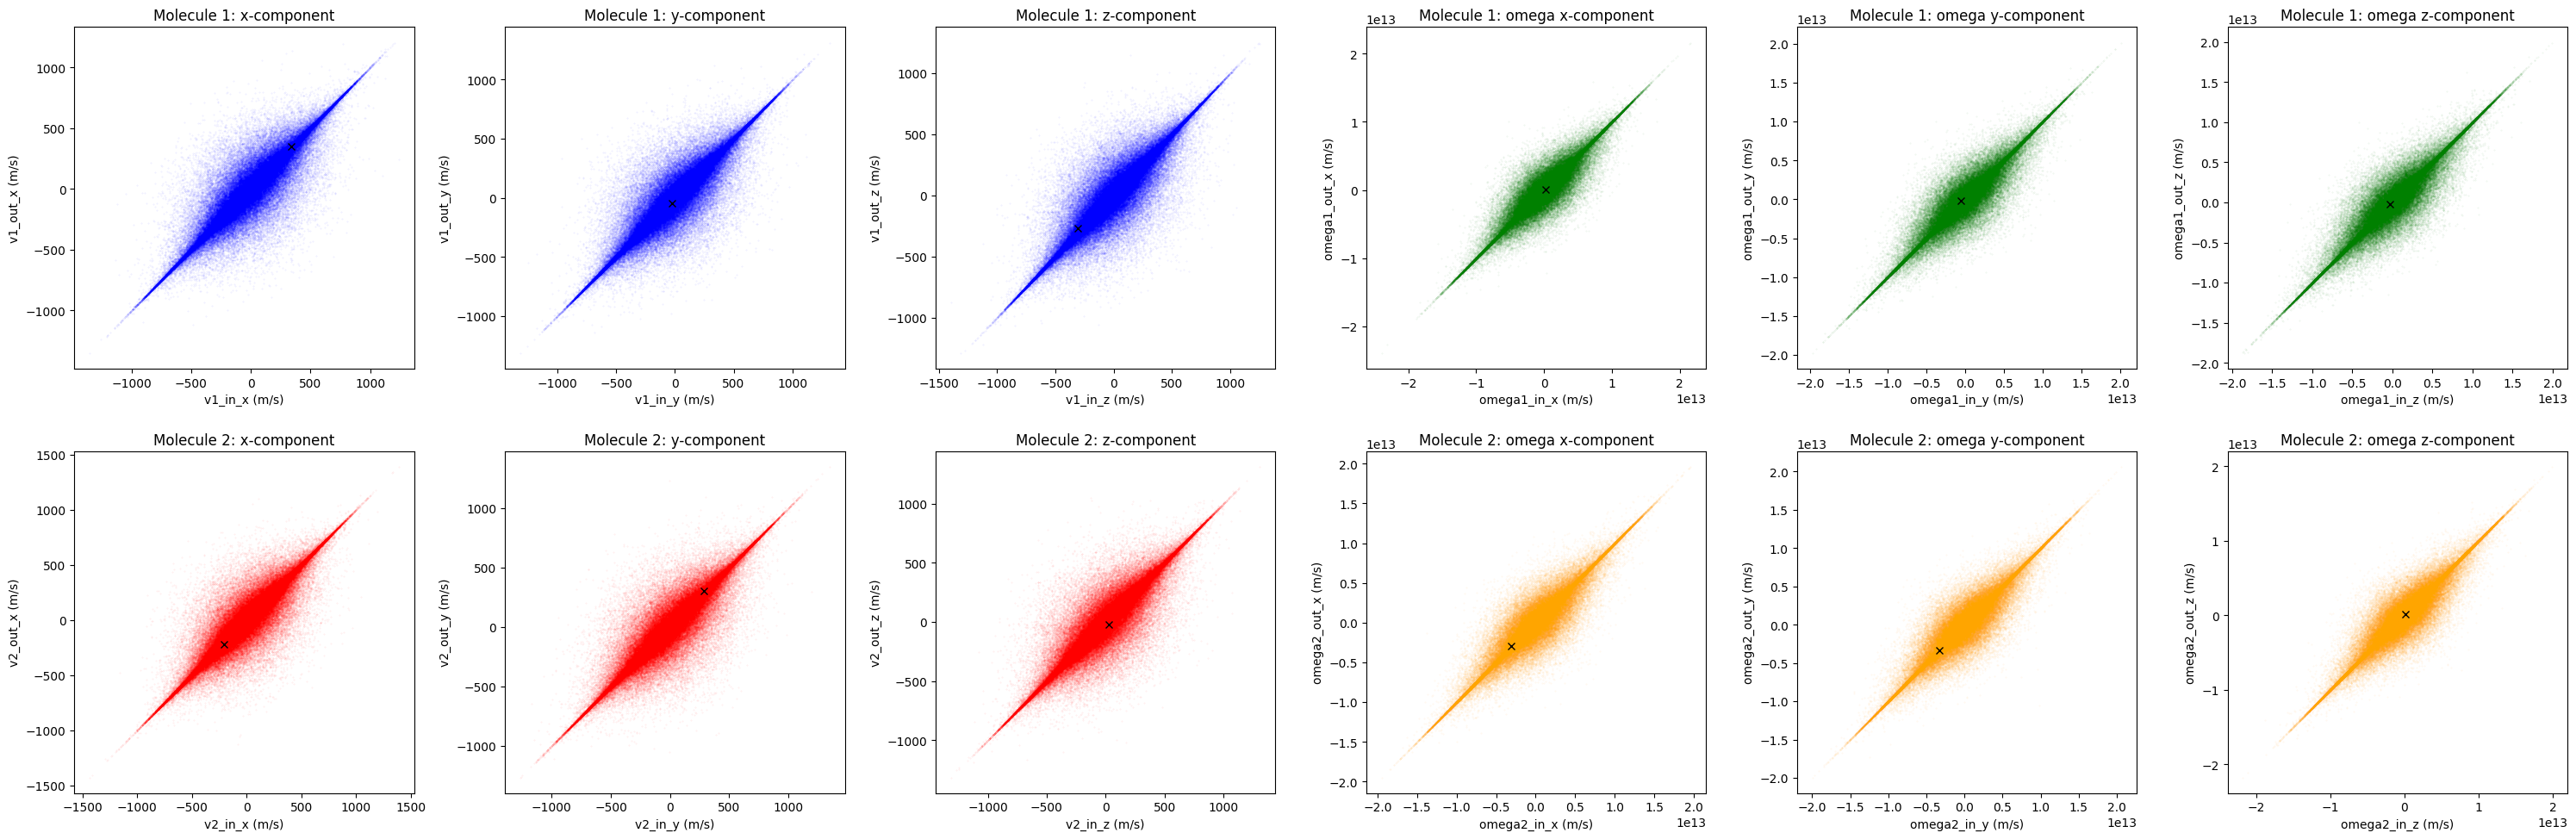

In [ ]:
dotsize = 0.1
alpha = 0.1

## Molecule 1
# Translational velocity
fig, ax = plt.subplots(2,6, figsize=(30,10))
ax[0,0].scatter(rawdata[:,0], rawdata[:,12], alpha=0.1, color='blue', s=dotsize)
ax[0,0].plot(rawdata[0,0], rawdata[0,12], color='black', marker='x')
ax[0,0].set_xlabel('v1_in_x (m/s)')
ax[0,0].set_ylabel('v1_out_x (m/s)')
ax[0,0].set_title('Molecule 1: x-component')

ax[0,1].scatter(rawdata[:,1], rawdata[:,13], alpha=0.1, color='blue', s=dotsize)
ax[0,1].plot(rawdata[0,1], rawdata[0,13], color='black', marker='x')
ax[0,1].set_xlabel('v1_in_y (m/s)')
ax[0,1].set_ylabel('v1_out_y (m/s)')
ax[0,1].set_title('Molecule 1: y-component')

ax[0,2].scatter(rawdata[:,2], rawdata[:,14], alpha=0.1, color='blue', s=dotsize)
ax[0,2].plot(rawdata[0,2], rawdata[0,14], color='black', marker='x')
ax[0,2].set_xlabel('v1_in_z (m/s)')
ax[0,2].set_ylabel('v1_out_z (m/s)')
ax[0,2].set_title('Molecule 1: z-component')

# Rotational velocity
ax[0,3].scatter(rawdata[:,6], rawdata[:,18], alpha=0.1, color='green', s=dotsize)
ax[0,3].plot(rawdata[0,6], rawdata[0,18], color='black', marker='x')
ax[0,3].set_xlabel('omega1_in_x (m/s)')
ax[0,3].set_ylabel('omega1_out_x (m/s)')
ax[0,3].set_title('Molecule 1: omega x-component')

ax[0,4].scatter(rawdata[:,7], rawdata[:,19], alpha=0.1, color='green', s=dotsize)
ax[0,4].plot(rawdata[0,7], rawdata[0,19], color='black', marker='x')
ax[0,4].set_xlabel('omega1_in_y (m/s)')
ax[0,4].set_ylabel('omega1_out_y (m/s)')
ax[0,4].set_title('Molecule 1: omega y-component')

ax[0,5].scatter(rawdata[:,8], rawdata[:,20], alpha=0.1, color='green', s=dotsize)
ax[0,5].plot(rawdata[0,8], rawdata[0,20], color='black', marker='x')
ax[0,5].set_xlabel('omega1_in_z (m/s)')
ax[0,5].set_ylabel('omega1_out_z (m/s)')
ax[0,5].set_title('Molecule 1: omega z-component')

## Molecule 2
# Translational velocity
ax[1,0].scatter(rawdata[:,3], rawdata[:,15], alpha=0.1, color='red', s=dotsize)
ax[1,0].plot(rawdata[0,3], rawdata[0,15], color='black', marker='x')
ax[1,0].set_xlabel('v2_in_x (m/s)')
ax[1,0].set_ylabel('v2_out_x (m/s)')
ax[1,0].set_title('Molecule 2: x-component')

ax[1,1].scatter(rawdata[:,4], rawdata[:,16], alpha=0.1, color='red', s=dotsize)
ax[1,1].plot(rawdata[0,4], rawdata[0,16], color='black', marker='x')
ax[1,1].set_xlabel('v2_in_y (m/s)')
ax[1,1].set_ylabel('v2_out_y (m/s)')
ax[1,1].set_title('Molecule 2: y-component')

ax[1,2].scatter(rawdata[:,5], rawdata[:,17], alpha=0.1, color='red', s=dotsize)
ax[1,2].plot(rawdata[0,5], rawdata[0,17], color='black', marker='x')
ax[1,2].set_xlabel('v2_in_z (m/s)')
ax[1,2].set_ylabel('v2_out_z (m/s)')
ax[1,2].set_title('Molecule 2: z-component')

# Rotational velocity
ax[1,3].scatter(rawdata[:,9], rawdata[:,21], alpha=0.1, color='orange', s=dotsize)
ax[1,3].plot(rawdata[0,9], rawdata[0,21], color='black', marker='x')
ax[1,3].set_xlabel('omega2_in_x (m/s)')
ax[1,3].set_ylabel('omega2_out_x (m/s)')
ax[1,3].set_title('Molecule 2: omega x-component')

ax[1,4].scatter(rawdata[:,10], rawdata[:,22], alpha=0.1, color='orange', s=dotsize)
ax[1,4].plot(rawdata[0,10], rawdata[0,22], color='black', marker='x')
ax[1,4].set_xlabel('omega2_in_y (m/s)')
ax[1,4].set_ylabel('omega2_out_y (m/s)')
ax[1,4].set_title('Molecule 2: omega y-component')

ax[1,5].scatter(rawdata[:,11], rawdata[:,23], alpha=0.1, color='orange', s=dotsize)
ax[1,5].plot(rawdata[0,11], rawdata[0,23], color='black', marker='x')
ax[1,5].set_xlabel('omega2_in_z (m/s)')
ax[1,5].set_ylabel('omega2_out_z (m/s)')
ax[1,5].set_title('Molecule 2: omega z-component')

plt.tight_layout()

In [ ]:
import pandas as pd
labels = ['v1in(1)', 'v1in(2)', 'v1in(3)', 'v2in(1)', 'v2in(2)', 'v2in(3)','omega1_in(1)', 'omega1_in(2)', 'omega1_in(3)', 'omega2_in(1)', 'omega2_in(2)', 'omega2_in(3)','v1out(1)', 'v1out(2)', 'v1out(3)', 'v2out(1)', 'v2out(2)', 'v2out(3)','omega1out(1)', 'omega1out(2)', 'omega1out(3)', 'omega2out(1)', 'omega2out(2)', 'omega2out(3)']
coll1 = pd.DataFrame(rawdata[:1], columns=labels)
coll1

,v1in(1),v1in(2),v1in(3),v2in(1),v2in(2),v2in(3),omega1_in(1),omega1_in(2),omega1_in(3),omega2_in(1),...,v1out(3),v2out(1),v2out(2),v2out(3),omega1out(1),omega1out(2),omega1out(3),omega2out(1),omega2out(2),omega2out(3)
0,337.442222,-24.940758,-311.317636,-204.834487,286.254059,25.735519,2.629764e+11,-5.229765e+11,-2.912929e+11,-3.052854e+12,...,-266.508527,-219.011813,305.919374,-19.07359,9.304846e+10,-2.057252e+11,-1.619513e+11,-2.979395e+12,-3.318984e+12,1.410629e+11


In [ ]:
# Take velocities of molecule 1
coll1_mol1 = coll1[['v1in(1)', 'v1in(2)', 'v1in(3)', 'omega1_in(1)', 'omega1_in(2)', 'omega1_in(3)']]
coll1_mol1_out = coll1[['v1out(1)','v1out(2)','v1out(3)', 'omega1out(1)','omega1out(2)','omega1out(3)']]
coll1_mol1


,v1in(1),v1in(2),v1in(3),omega1_in(1),omega1_in(2),omega1_in(3)
0,337.442222,-24.940758,-311.317636,2.629764e+11,-5.229765e+11,-2.912929e+11


In [ ]:
# Make prediction
model = torch.load("mdn_o2o2_collision_model.pth")
pi, mu, sigma = torch.empty(0,K), torch.empty(0,K,output_dim), torch.empty(0,K,output_dim)

model.eval()
with torch.no_grad():
    input_tensor = torch.tensor(coll1_mol1.values, dtype=torch.float32)
    input_tensor_norm = (input_tensor - in_mean) / in_std
    pi, mu, sigma = model(input_tensor_norm)

print("pi:",pi)
print("mu:",mu)
print("sigma:",sigma)

AttributeError: 'collections.OrderedDict' object has no attribute 'eval'

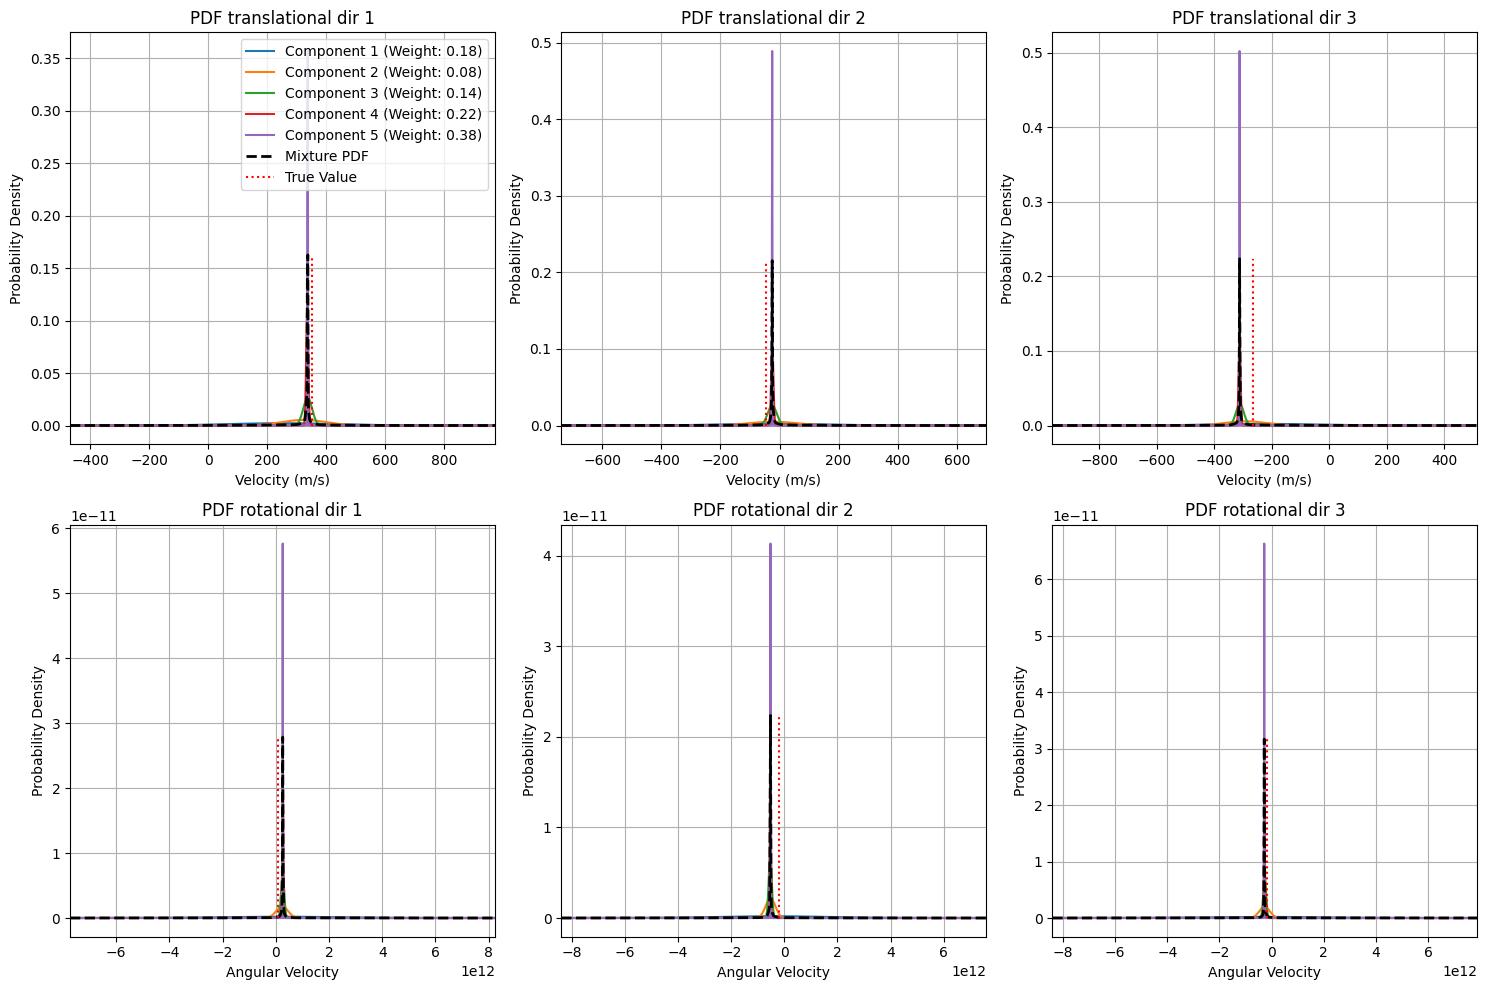

In [ ]:
# Visualize PDFs (unnormalized / physical units)
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Convert network outputs from normalized space back to physical units:
# y_phys = y_norm * out_std + out_mean
# std_phys = std_norm * out_std
mixtureweights = pi.detach().cpu().numpy().squeeze()  # (K,) for a single sample
mu_np = mu.detach().cpu().numpy().squeeze(0)          # (K, D)
sigma_np = sigma.detach().cpu().numpy().squeeze(0)    # (K, D)
out_mean_np = out_mean.detach().cpu().numpy().squeeze(0)  # (D,)
out_std_np = out_std.detach().cpu().numpy().squeeze(0)    # (D,)

mu_phys = mu_np * out_std_np + out_mean_np            # (K, D)
sigma_phys = sigma_np * out_std_np                    # (K, D)

n_std = 4.0
num_points = 1000

# Plot PDFs for each output dimension in physical units
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
for d in range(output_dim):
    # Choose an x-range that covers all mixture components
    x_min = np.min(mu_phys[:, d] - n_std * sigma_phys[:, d])
    x_max = np.max(mu_phys[:, d] + n_std * sigma_phys[:, d])
    if (not np.isfinite(x_min)) or (not np.isfinite(x_max)) or (x_min == x_max):
        x_min = float(mu_phys[0, d] - 1.0)
        x_max = float(mu_phys[0, d] + 1.0)

    x = np.linspace(x_min, x_max, num_points)

    # Component PDFs + mixture PDF
    mixture_pdf = np.zeros_like(x)
    for k in range(K):
        comp_pdf = norm.pdf(x, loc=mu_phys[k, d], scale=sigma_phys[k, d])
        mixture_pdf += mixtureweights[k] * comp_pdf
        ax[d // 3, d % 3].plot(x, comp_pdf, label=f'Component {k+1} (Weight: {mixtureweights[k]:.2f})')

    ax[d // 3, d % 3].plot(x, mixture_pdf, 'k--', linewidth=2.0, label='Mixture PDF')
    mixpdfmax = np.max(mixture_pdf)
    ax[d//3, d % 3].vlines(coll1_mol1_out.values[0][d], 0, mixpdfmax, color='r', linestyles='dotted', label='True Value')

    if d < 3:
        ax[d // 3, d % 3].set_title(f'PDF translational dir {d+1}')
        ax[d // 3, d % 3].set_xlabel('Velocity (m/s)')
    else:
        ax[d // 3, d % 3].set_title(f'PDF rotational dir {d-2}')
        ax[d // 3, d % 3].set_xlabel('Angular Velocity')

    ax[d // 3, d % 3].set_xlim(x_min, x_max)
    ax[d // 3, d % 3].set_ylabel('Probability Density')
    if d == 0:
        ax[d // 3, d % 3].legend(loc='upper right')
    ax[d // 3, d % 3].grid()

plt.tight_layout()
plt.show()
